In [20]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import mesa
import pandas as pd

from mesa.visualization import SolaraViz, make_plot_component, make_space_component

In [21]:
def update_expectation(expected_outcome, outcome, alpha):
    expected_outcome += alpha * (outcome - expected_outcome)
    return expected_outcome
"""This function enacts the Rescorla-Wagner rule, where with every step the agent can
reinforce their position on whether to use AI or not in the next step"""


class AdoptionAgent(mesa.Agent):
    """An agent with skill, and the ability to choose to use artificial intelligence tools,
    that can compete to complete a task if it meets another agent"""

    def __init__(self, model):
        """initialize an AdoptionAgent instance.

        Args:
            model: A model instance

            self.skill: Is a normally distributed set skill level between 0 and 1 that can increase by
            succesfully winning at tasks without using AI or decrease by using AI

            self.ability: Is a combination of skill, luck and AI usage between 0 and 1 that
            is the metric used to see who wins in a 'compete' instance.

            self.wins: Is a value that counts the amount of times the chosen agent won.

            self.losses: Counts the losses.

            self.aichoice: Is the outcome of their decision to either use or not use AI, either a 0 or a 1 respectively.

            self.expected: Is the leaning of an agent towards using or not using AI.

            self.evidence: Is the outcome of the competition that suggests if using AI was useful or not.
            If they won without using AI evidence will be set to 0, if they lost and used AI it will also be set to 0.
            If they lost simply then it will be set to 1 and if they won using AI it will also be set to 1.
            This value sets the direction for the update_expectation function.
        """
        super().__init__(model)
        
        "Preset starting variables for the model:"
        self.skill = np.clip(np.random.normal(loc=0.5, scale=0.1), 0, 1)
        self.ability = 0
        self.wins = 1
        self.losses = 1
        self.aichoice = 0
        self.expected = 0.5
        self.evidence = 0
        self.luck = 0

        "Variables that can be changed between batches:"
        self.alpha = 0.05
        self.beta = 0.01
        self.AISkillLevel = self.model.AISkillLevel
        self.middle = 0.10
        self.scaler = 0.02
        


    def move(self):
        """move to a random neighboring cell."""
        possible_steps = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)

    def compete(self):
        """One agent picks another agent randomly and compares scores updating all info"""
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        if len(cellmates) > 1:
            other = self.random.choice(cellmates)


            self.aichoice = np.random.choice([0, 1], p=[1 - self.expected, self.expected])
            other.aichoice = np.random.choice([0, 1], p=[1 - other.expected, other.expected])

            self.luck = np.clip(np.random.normal(loc= self.middle , scale= self.scaler ), 0, 1)
            other.luck = np.clip(np.random.normal(loc= self.middle , scale= self.scaler ), 0, 1)

            self.ability = np.clip((self.skill + self.luck) * (1 - self.aichoice) + (self.AISkillLevel * self.aichoice), 0, 1)
            other.ability = np.clip((other.skill + other.luck) * (1 - other.aichoice) + (other.AISkillLevel * other.aichoice), 0, 1)
            self.skill = np.clip(self.skill + ((-1)**self.aichoice ) * self.beta, 0, 1)
            if self.ability > other.ability:
                self.wins += 1
                self.evidence = 1 * self.aichoice
                self.expected = update_expectation(self.expected, self.evidence, self.alpha)

            else:
                self.losses += 1
                self.evidence = 1 - self.aichoice
                self.expected = update_expectation(self.expected, self.evidence, self.alpha)




    def step(self):
        """do one step of the agent."""
        self.move()
        self.compete()


class AdoptionModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self,
                 alpha = 0.05,
                 beta = 0.01,
                 AISkillLevel = 0.1,
                 middle = 0.05,
                 scaler = 0.02,
                 n=80,
                 width=10,
                 height=10,
                 seed=None):
        
        """Initialize a competition instance.

        Args:
            N: The number of agents.
            width: width of the grid.
            height: Height of the grid.
        """
        super().__init__(seed=seed)
        self.num_agents = n
        self.alpha = alpha
        self.beta = beta
        self.AISkillLevel = AISkillLevel
        self.middle = middle
        self.scaler = scaler
        self.grid = mesa.space.MultiGrid(width, height, True)

        # Create agents
        agents = AdoptionAgent.create_agents(model=self, n=n)
        # Create x and y positions for agents
        x = self.rng.integers(0, self.grid.width, size=(n,))
        y = self.rng.integers(0, self.grid.height, size=(n,))
        for a, i, j in zip(agents, x, y):
            # Add the agent to a random grid cell
            self.grid.place_agent(a, (i, j))

        self.datacollector = mesa.DataCollector(
            agent_reporters={
                "Skill": "skill",
                "Ability": "ability",
                "Wins": "wins",
                "Losses": "losses",
                "AI Usage Choice": "aichoice",
                "Expected": "expected",
                "Evidence": "evidence",
                "Luck" : "luck",
                "AI Skill Level" : "AISkillLevel"
            }
        )
        self.datacollector.collect(self)

    def step(self):
        """do one step of the model"""
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

In [ ]:
params = {
          "AISkillLevel": [0.1, 0.25, 0.5, 0.7, 0.9],
          }

results = mesa.batch_run(
    AdoptionModel,
    parameters=params,
    iterations=1,
    max_steps=10000,
    number_processes=1,
    data_collection_period=1,
    display_progress=True,
)


df = pd.DataFrame(results)
print(df.keys())

  0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
df.head(-10)

,RunId,iteration,Step,AISkillLevel,AgentID,Skill,Ability,Wins,Losses,AI Usage Choice,Expected,Evidence,Luck,AI Skill Level
0,0,0,0,0.1,1,0.612300,0.000000,1,1,0,0.500000,0,0.000000,0.1
1,0,0,0,0.1,2,0.363656,0.000000,1,1,0,0.500000,0,0.000000,0.1
2,0,0,0,0.1,3,0.408403,0.000000,1,1,0,0.500000,0,0.000000,0.1
3,0,0,0,0.1,4,0.577783,0.000000,1,1,0,0.500000,0,0.000000,0.1
4,0,0,0,0.1,5,0.279967,0.000000,1,1,0,0.500000,0,0.000000,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4000385,4,0,10000,0.9,66,0.480000,0.900000,993,4438,1,0.464509,0,0.130682,0.9
4000386,4,0,10000,0.9,67,0.090000,0.175631,984,4463,0,0.656904,1,0.085631,0.9
4000387,4,0,10000,0.9,68,0.030000,0.900000,1004,4561,1,0.582859,0,0.125575,0.9
4000388,4,0,10000,0.9,69,0.000000,0.900000,922,4509,1,0.459293,0,0.063473,0.9


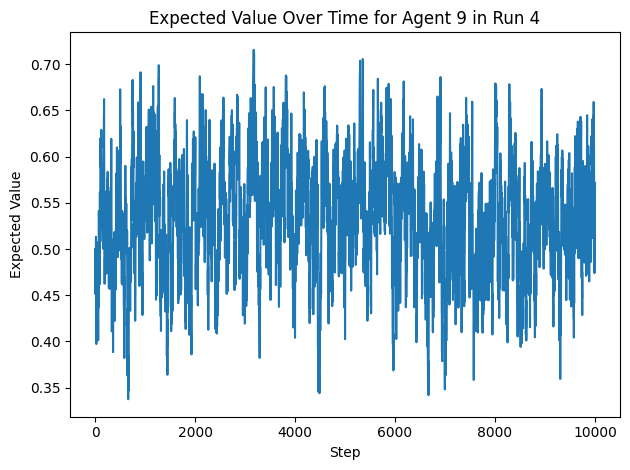

In [ ]:
df_run1 = df[df['RunId'] == 3]

random_agent_id = np.random.choice(range(1, 71))
df_run1_RandomAgent = df_run1[df_run1['AgentID'] == random_agent_id ]


sns.lineplot(data=df_run1_RandomAgent, x='Step', y='Expected')

plt.title(f'Expected Value Over Time for Agent {random_agent_id} in Run 4')
plt.xlabel('Step')
plt.ylabel('Expected Value')
plt.tight_layout()
plt.show()

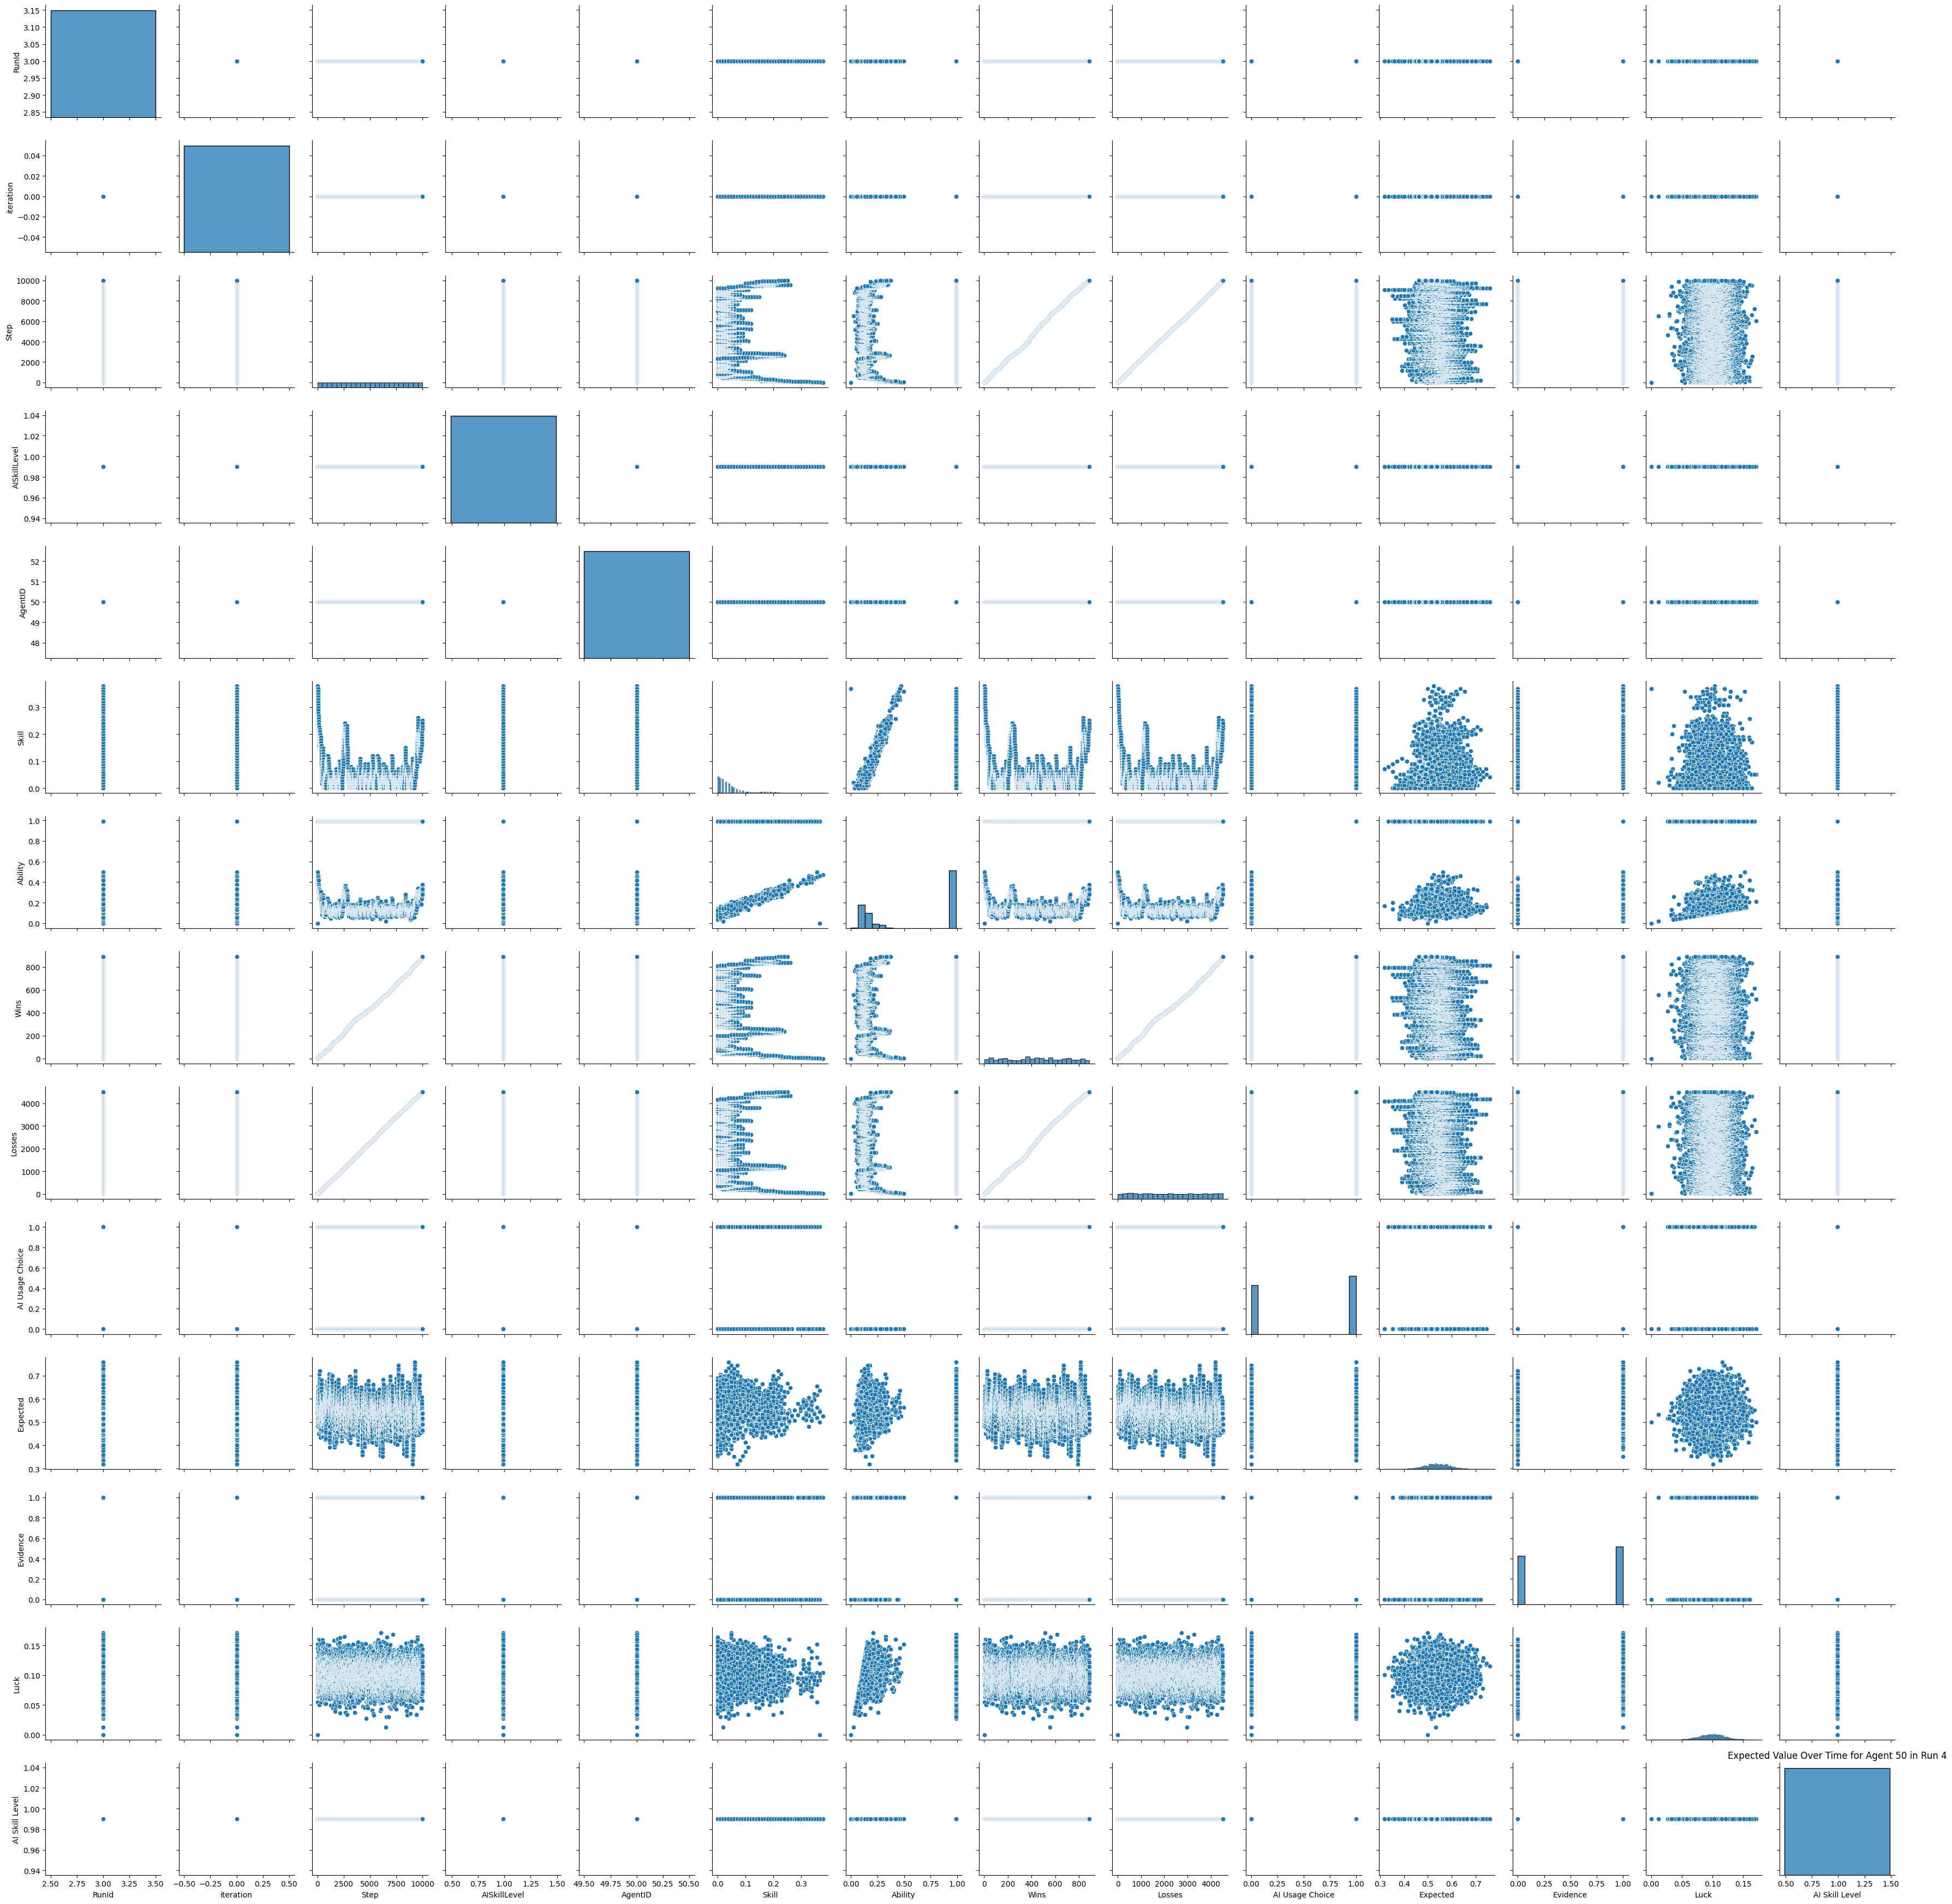

In [112]:
df_run1 = df[df['RunId'] == 3]

random_agent_id = np.random.choice(range(1, 71))
df_run1_RandomAgent = df_run1[df_run1['AgentID'] == random_agent_id ]


sns.pairplot(data=df_run1_RandomAgent)

plt.title(f'Expected Value Over Time for Agent {random_agent_id} in Run 4')
plt.xlabel('Step')
plt.ylabel('Expected Value')
plt.tight_layout()
plt.show()

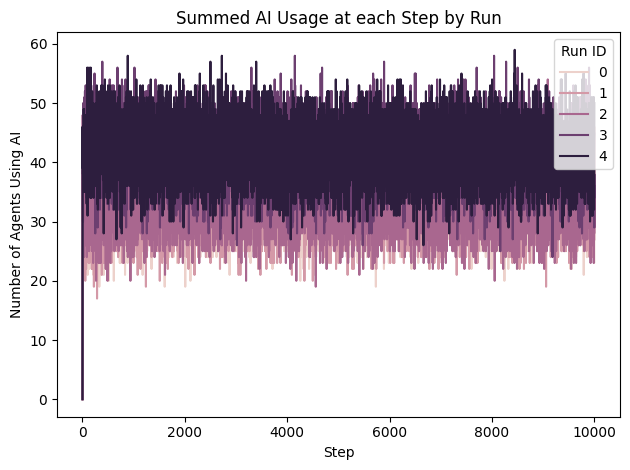

In [113]:
ai_usage_per_run = df.groupby(['RunId', 'Step'])['AI Usage Choice'].sum().reset_index()

sns.lineplot(data=ai_usage_per_run, x='Step', y='AI Usage Choice', hue='RunId')

plt.title('Summed AI Usage at each Step by Run')
plt.xlabel('Step')
plt.ylabel('Number of Agents Using AI')
plt.legend(title='Run ID', loc='upper right')
plt.tight_layout()
plt.show()

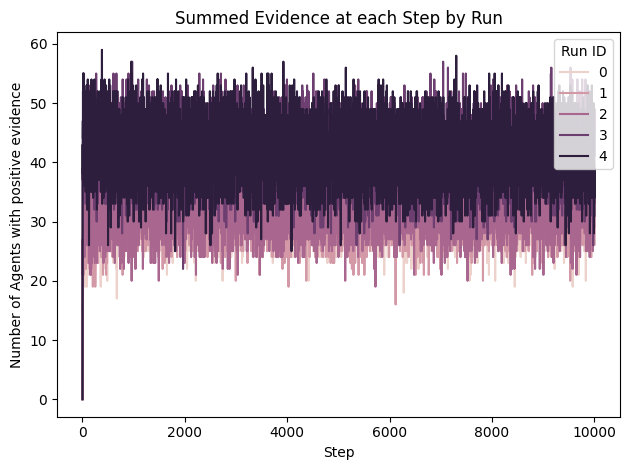

In [114]:
ai_usage_per_run = df.groupby(['RunId', 'Step'])['Evidence'].sum().reset_index()

sns.lineplot(data=ai_usage_per_run, x='Step', y='Evidence', hue='RunId')

plt.title('Summed Evidence at each Step by Run')
plt.xlabel('Step')
plt.ylabel('Number of Agents with positive evidence')
plt.legend(title='Run ID', loc='upper right')
plt.tight_layout()
plt.show()

In [115]:
step1 = df[(df['RunId'] == 3) & (df['Step'] == 1)]

low_thresh = step1['Skill'].quantile(0.2)
high_thresh = step1['Skill'].quantile(0.8)

low_thresh


np.float64(0.3906655403786045)

In [116]:
high_thresh

np.float64(0.5800370867904897)

In [117]:
#Taking AgentIDs in bottom and top 20%
low_skill_ids = step1[step1['Skill'] <= low_thresh]['AgentID']
high_skill_ids = step1[step1['Skill'] >= high_thresh]['AgentID']

low_skill_ids

2400323     4
2400324     5
2400325     6
2400346    27
2400349    30
2400359    40
2400369    50
2400371    52
2400373    54
2400375    56
2400380    61
2400383    64
2400385    66
2400392    73
2400395    76
2400396    77
Name: AgentID, dtype: int64

In [118]:
#Filtering full Run data for those agents
df_low = df[(df['RunId'] == 3) & (df['AgentID'].isin(low_skill_ids))]
df_high = df[(df['RunId'] == 3) & (df['AgentID'].isin(high_skill_ids))]

df_high

,RunId,iteration,Step,AISkillLevel,AgentID,Skill,Ability,Wins,Losses,AI Usage Choice,Expected,Evidence,Luck,AI Skill Level
2400246,3,0,0,0.99,7,0.657664,0.000000,1,1,0,0.500000,0,0.000000,0.99
2400250,3,0,0,0.99,11,0.606340,0.000000,1,1,0,0.500000,0,0.000000,0.99
2400253,3,0,0,0.99,14,0.637213,0.000000,1,1,0,0.500000,0,0.000000,0.99
2400256,3,0,0,0.99,17,0.593059,0.000000,1,1,0,0.500000,0,0.000000,0.99
2400260,3,0,0,0.99,21,0.590560,0.000000,1,1,0,0.500000,0,0.000000,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3200308,3,0,10000,0.99,69,0.060000,0.194155,869,4487,0,0.615134,1,0.144155,0.99
3200311,3,0,10000,0.99,72,1.000000,1.000000,2260,3301,0,0.227849,0,0.116643,0.99
3200313,3,0,10000,0.99,74,1.000000,1.000000,2168,3306,0,0.413017,1,0.099622,0.99
3200317,3,0,10000,0.99,78,0.030000,0.126147,1002,4423,0,0.531149,1,0.096147,0.99


In [119]:
df_low_avg = df_low.groupby('Step')['Expected'].mean().reset_index()
df_low_avg['Group'] = 'Bottom 20% Skill'

df_high_avg = df_high.groupby('Step')['Expected'].mean().reset_index()
df_high_avg['Group'] = 'Top 20% Skill'

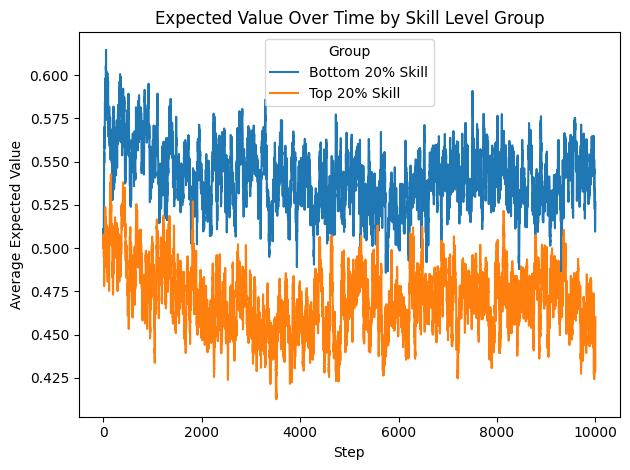

In [120]:
combined = pd.concat([df_low_avg, df_high_avg])

sns.lineplot(data=combined, x='Step', y='Expected', hue='Group')

plt.title('Expected Value Over Time by Skill Level Group')
plt.xlabel('Step')
plt.ylabel('Average Expected Value')
plt.tight_layout()
plt.show()

In [121]:
df_low_avg = df_low.groupby('Step')['Skill'].mean().reset_index()
df_low_avg['Group'] = 'Bottom 20% Skill'

df_high_avg = df_high.groupby('Step')['Skill'].mean().reset_index()
df_high_avg['Group'] = 'Top 20% Skill'

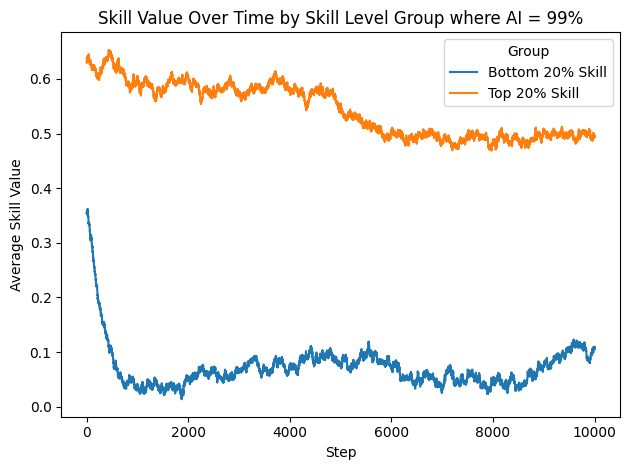

In [123]:
combined = pd.concat([df_low_avg, df_high_avg])

sns.lineplot(data=combined, x='Step', y='Skill', hue='Group')

plt.title('Skill Value Over Time by Skill Level Group where AI = 99%')
plt.xlabel('Step')
plt.ylabel('Average Skill Value')
plt.tight_layout()
plt.show()